# Tiny Transformer from Scratch (PyTorch)
### Next-token prediction on Tiny Shakespeare (BPE vocab ≤ 500)

This notebook implements a **minimal Transformer language model** from scratch, trains it on the **Tiny Shakespeare** corpus for next-token prediction, and visualizes **attention patterns**.

**Highlights**
- Subword tokenization (BPE) with vocab size ≤ 500
- Causal multi-head self-attention (no attending to future tokens)
- Feed-forward network + residual connections + **RMSNorm**
- Training/validation loss curves + **Perplexity (PPL)**
- Attention heatmaps + optional sample generation

> Note: This is intentionally lightweight (2 blocks, hidden size ≤ 128) but architecturally faithful.


## 0. Setup

Install dependencies:  
`pip install torch tokenizers numpy pandas matplotlib`


In [ ]:
import sys
print(sys.executable)
print(sys.version)

/usr/bin/python3
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
import os, math, random, re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, normalizers

# Reproducibility
RANDOM_STATE = 100
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 0.1 Configuration (FAST vs Full Training)

Toggle `FAST_DEV_RUN` for quick CPU runs or more complete GPU training.

In [ ]:
FAST_DEV_RUN = True  # set False for longer training / GPU

if FAST_DEV_RUN:
    vocab_size = 500
    block_size = 64
    stride = 10
    batch_size = 64
    d_model = 96
    n_layers = 2
    n_heads = 4
    dropout = 0.1
    lr = 1e-3
    epochs = 10
else:
    vocab_size = 500
    block_size = 128
    stride = 4
    batch_size = 128
    d_model = 128
    n_layers = 2
    n_heads = 4
    dropout = 0.2
    lr = 5e-4
    epochs = 50  # early stopping will cut it short

d_ff = 4 * d_model

## 1. Data loading (portable)

We download Tiny Shakespeare if not present locally.


In [ ]:
import urllib.request

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

txt_path = DATA_DIR / "tiny_shakespeare.txt"
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not txt_path.exists():
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(url, txt_path)
    print("Saved to:", txt_path.resolve())

text = txt_path.read_text(encoding="utf-8")
print("Characters:", len(text))
print(text[:400])


Characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


## 2. Tokenization (BPE, vocab ≤ 500)

We train a ByteLevel BPE tokenizer on the corpus and convert text to integer token ids.


In [ ]:
tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.normalizer = normalizers.Sequence([normalizers.NFKC()])
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)

trainer = trainers.BpeTrainer(
    vocab_size=vocab_size,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"],
    show_progress=True
)

tokenizer.train_from_iterator([text], trainer=trainer)
tokenizer.decoder = decoders.ByteLevel()

def encode_text(s: str):
    return tokenizer.encode(s).ids

def decode_ids(ids):
    return tokenizer.decode(ids)

model_vocab_size = tokenizer.get_vocab_size()
print("Vocabulary size:", model_vocab_size)


Vocabulary size: 500


## 3. Sequence formatting

We split the token stream into overlapping fixed-length sequences of length `block_size`.
For each sequence:
- **Input**: first N tokens
- **Target**: same sequence shifted by one position (next-token prediction)


In [ ]:
ids = encode_text(text)

# build sequences
seqs = []
tgts = []
for i in range(0, len(ids) - block_size - 1, stride):
    chunk = ids[i:i+block_size+1]
    x = chunk[:-1]
    y = chunk[1:]
    seqs.append(x)
    tgts.append(y)

seqs = np.array(seqs, dtype=np.int64)
tgts = np.array(tgts, dtype=np.int64)

print("Num sequences:", len(seqs))
print("Example input:", seqs[0][:10])
print("Example target:", tgts[0][:10])


Num sequences: 129264
Example input: [ 68 484 233  87  49  66  92  12  67  16]
Example target: [484 233  87  49  66  92  12  67  16  45]


## 4. Train/validation split (80/20)

No test split is needed for this assignment.


In [ ]:
n_total = len(seqs)
n_train = int(0.8 * n_total)

train_seqs, val_seqs = seqs[:n_train], seqs[n_train:]
train_tgts, val_tgts = tgts[:n_train], tgts[n_train:]

print("Train sequences:", len(train_seqs))
print("Val sequences:", len(val_seqs))


Train sequences: 103411
Val sequences: 25853


## 5. DataLoaders


In [ ]:
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

def make_loader(X, Y, batch_size=128, shuffle=True):
    return DataLoader(SeqDataset(X, Y), batch_size=batch_size, shuffle=shuffle, drop_last=True)

train_loader = make_loader(train_seqs, train_tgts, batch_size=batch_size, shuffle=True)
val_loader   = make_loader(val_seqs, val_tgts, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)


Batch shapes: torch.Size([128, 128]) torch.Size([128, 128])


## 6. Building blocks: sinusoidal positional encoding, RMSNorm, Multi-Head Causal Self-Attention

We use a causal mask so token *t* cannot attend to tokens > *t*.


In [ ]:
def sinusoidal_positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe.unsqueeze(0)  # (1, max_len, d_model)

class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x * (self.scale / rms)

class MultiHeadCausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        B, T, D = x.shape

        qkv = self.qkv(x)  # (B, T, 3D)
        q, k, v = qkv.split(D, dim=-1)

        # reshape into heads: (B, n_heads, T, head_dim)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # scaled dot-product attention
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B, h, T, T)

        # causal mask: prevent attending to future tokens
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, 0.0)
        attn = self.dropout(attn)

        out = attn @ v  # (B, h, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # merge heads
        out = self.out(out)
        out = self.dropout(out)

        return out, attn  # attn for visualization


## 7. Transformer block + language model head


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = MultiHeadCausalSelfAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        a, attn = self.attn(self.norm1(x))
        x = x + a
        x = x + self.ff(self.norm2(x))
        return x, attn

class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_layers: int, n_heads: int, d_ff: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pos_emb", sinusoidal_positional_encoding(max_seq_len, d_model))
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight

    def forward(self, idx):
        B, T = idx.shape
        x = self.token_emb(idx) + self.pos_emb[:, :T, :].to(idx.device)
        attn_list = []
        for blk in self.blocks:
            x, attn = blk(x)
            attn_list.append(attn)
        x = self.final_norm(x)
        logits = self.lm_head(x)  # (B, T, vocab)
        return logits, attn_list


## 8. Training setup

We train using token-level cross-entropy loss.  
Perplexity (PPL) on validation is reported as `exp(val_loss)`.


In [ ]:
model = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    max_seq_len=block_size,
    dropout=dropout
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()


In [ ]:
def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_tokens = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits, _ = model(xb)  # (B,T,V)
            B, T, V = logits.shape
            loss = loss_fn(logits.view(B*T, V), yb.view(B*T))

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * (B * T)
        total_tokens += (B * T)

    return total_loss / total_tokens


## 9. Train + validate (with early stopping)


In [ ]:
train_losses, val_losses, val_ppls = [], [], []

best_val = float("inf")
best_state = None
patience = 2          # stop after 2 consecutive non-improvements
min_delta = 1e-4      # require at least this much improvement
bad = 0

for epoch in range(1, epochs + 1):
    tr = run_epoch(model, train_loader, train=True)
    va = run_epoch(model, val_loader, train=False)
    ppl = float(np.exp(va))

    train_losses.append(tr)
    val_losses.append(va)
    val_ppls.append(ppl)

    print(f"Epoch {epoch:02d} | train loss {tr:.4f} | val loss {va:.4f} | val PPL {ppl:.2f}")

    # Early stopping check
    if va < best_val - min_delta:
        best_val = va
        # store weights on CPU to avoid GPU memory creep
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print(f"Early stopping triggered. Best val loss: {best_val:.4f}")
            break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train loss 7.9092 | val loss 4.6529 | val PPL 104.88
Epoch 02 | train loss 4.4798 | val loss 4.2325 | val PPL 68.89
Epoch 03 | train loss 3.9867 | val loss 4.0094 | val PPL 55.11
Epoch 04 | train loss 3.7095 | val loss 3.8820 | val PPL 48.52
Epoch 05 | train loss 3.5289 | val loss 3.8077 | val PPL 45.05
Epoch 06 | train loss 3.3919 | val loss 3.7478 | val PPL 42.43
Epoch 07 | train loss 3.2877 | val loss 3.7175 | val PPL 41.16
Epoch 08 | train loss 3.2062 | val loss 3.7000 | val PPL 40.45
Epoch 09 | train loss 3.1413 | val loss 3.6650 | val PPL 39.06
Epoch 10 | train loss 3.0886 | val loss 3.6281 | val PPL 37.64
Epoch 11 | train loss 3.0436 | val loss 3.5938 | val PPL 36.37
Epoch 12 | train loss 3.0052 | val loss 3.5571 | val PPL 35.06
Epoch 13 | train loss 2.9728 | val loss 3.5439 | val PPL 34.60
Epoch 14 | train loss 2.9440 | val loss 3.5316 | val PPL 34.18
Epoch 15 | train loss 2.9196 | val loss 3.5055 | val PPL 33.30
Epoch 16 | train loss 2.8979 | val loss 3.4906 | val P

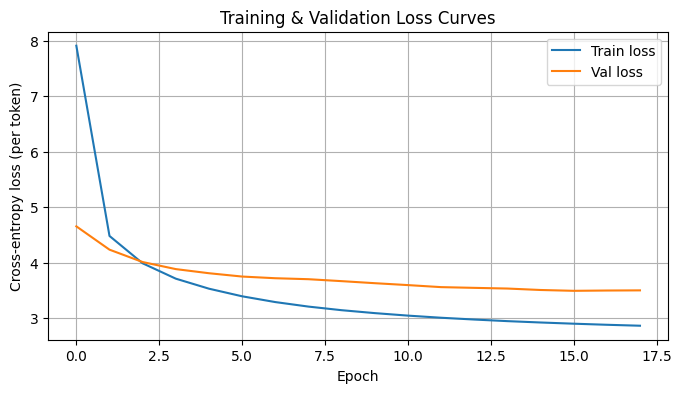

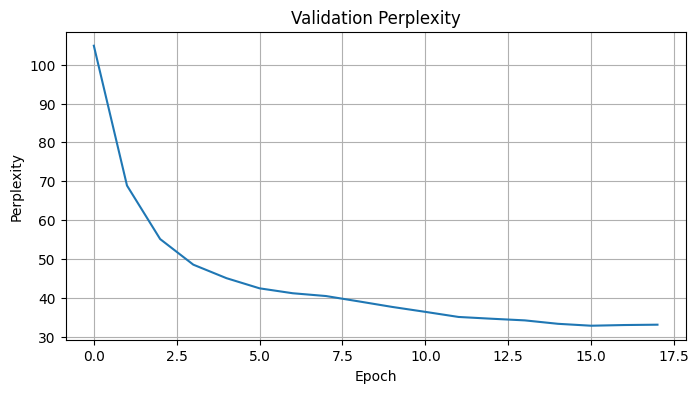

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss (per token)")
plt.title("Training & Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(val_ppls, label="Val PPL")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity")
plt.grid(True)
plt.show()


## 10. Attention visualization (heatmaps)

We visualize attention weights for a single validation example.
For multi-head attention, we show one heatmap per head for each layer.


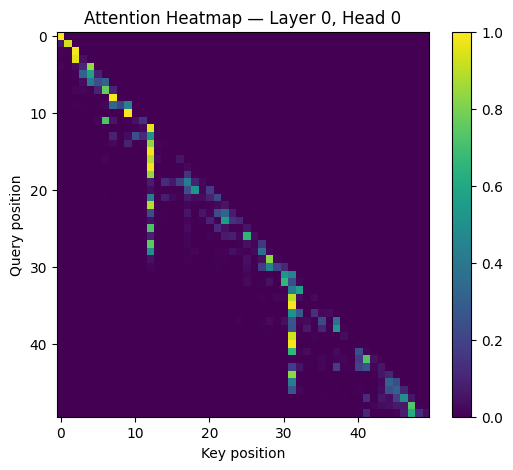

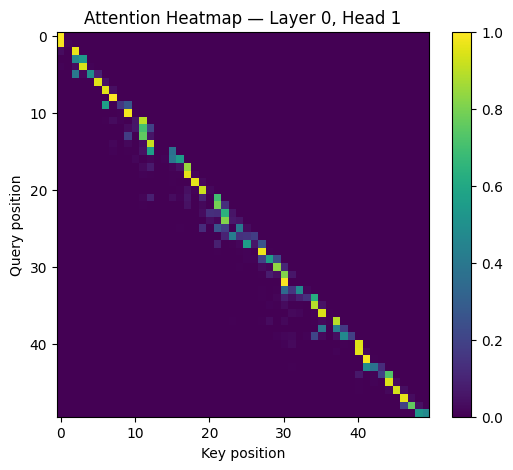

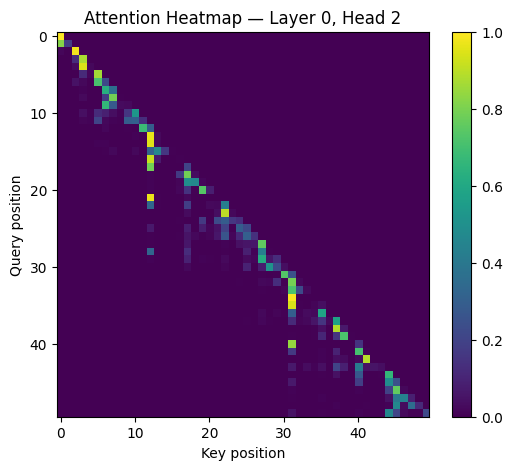

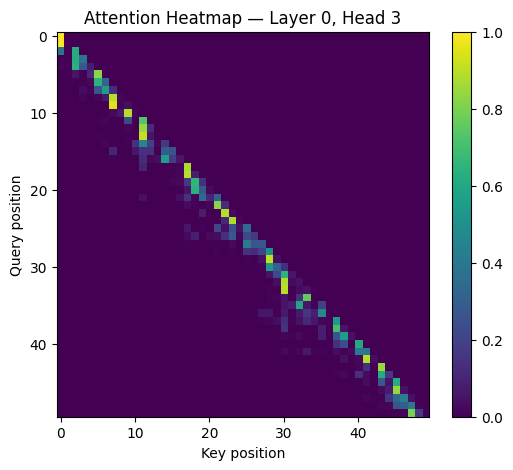

In [ ]:
def show_attention_maps(model, x_tokens, layer_idx=0, max_tokens=50):
    model.eval()
    with torch.no_grad():
        logits, attn_list = model(x_tokens)

    attn = attn_list[layer_idx][0].detach().cpu().numpy()  # (heads, T, T)
    T = attn.shape[-1]
    T = min(T, max_tokens)

    n_heads = attn.shape[0]
    for h in range(n_heads):
        plt.figure(figsize=(6,5))
        plt.imshow(attn[h][:T, :T], aspect="auto")
        plt.colorbar()
        plt.title(f"Attention Heatmap — Layer {layer_idx}, Head {h}")
        plt.xlabel("Key position")
        plt.ylabel("Query position")
        plt.show()

# Grab one example from val set
xb, yb = next(iter(val_loader))
x1 = xb[:1].to(device)
show_attention_maps(model, x1, layer_idx=0, max_tokens=50)


## 11. Sample Generation

We generate tokens autoregressively using temperature and top-k sampling.


In [ ]:
def generate_text(model, start_prompt: str, max_new_tokens: int = 120, temperature: float = 1.0, top_k: int = 50):
    model.eval()

    ids = encode_text(start_prompt)
    ids = ids[-block_size:]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        x_cond = x[:, -block_size:]
        with torch.no_grad():
            logits, _ = model(x_cond)
            next_logits = logits[:, -1, :]

        next_logits = next_logits / max(temperature, 1e-8)

        if top_k is not None and top_k > 0:
            vals, inds = torch.topk(next_logits, k=top_k)
            probs = F.softmax(vals, dim=-1)
            choice = torch.multinomial(probs, num_samples=1).item()
            next_id = inds[0, choice].item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        x = torch.cat([x, torch.tensor([[next_id]], device=device)], dim=1)

    return decode_ids(x[0].tolist())

print("temp=1.0, top_k=50:\n\n", generate_text(model, "ROMEO:", max_new_tokens=200, temperature=1.0, top_k=50), "\n\n\n")
print("temp=0.9, top_k=40:\n\n", generate_text(model, "ROMEO:", max_new_tokens=200, temperature=0.9, top_k=40))

temp=1.0, top_k=50:

  ROMEO:
Never I tell this, so do not the thunder.

LEONTES:
See.
HERMIONE:
Let me no truth, for he.

POMPEY:
Why, so we may, I think him
the mouth her, sir! Thou hast, of you,
the meet himself, I'll return'd.

PAULINA:
Is him that ever you
ne pawn.

LEONTES:
How, sir? But what is't women
Poler; a King Lewis of my deserve,
To bold a stock; how lack to dread with the move;
bright, is 



temp=0.9, top_k=40:

  ROMEO:
Leave not a traitor, duked on my heart
Much name from me to keeps.

MONTAGUE:
Plantagenet, prepare; for the king.

GLOUCESTER:
You have stay'd your general?

LADY ANNE:
Sir, I am in posterm'd: so has, and for cocks I do;
And therefore, I counsel to begether to perform it.

LADY ANNE:
Mark you, sir, my corsed you drink.

GLOUCESTER:
No, my lord, he, look on his part:
Nay, I desper


## 12. Discussion

- **Attention maps** often show strong diagonal structure (local context) plus occasional long-range jumps for names, punctuation, or clause structure.
- **Stability drivers**: learning rate and context length typically dominate; too-high LR destabilizes loss, longer contexts increase compute and may require more capacity.
- **Positional encodings** inject order information; without them, attention cannot distinguish permutations of tokens.
- **Compute bottlenecks**: attention is O(T²) in sequence length T; increasing `block_size` increases both runtime and memory.

**Main metric**: validation perplexity (PPL = exp(val cross-entropy)). Lower is better.
